# Mental Health Text Classification with Logistic Regression
### Vectorizers: CamemBERT (HuggingFace) + TF-IDF | Classifier: Logistic Regression with GridSearch

## 1. Libraries

In [1]:
# =========================
# Import Libraries
# =========================
# Standard data handling
import pandas as pd
import numpy as np
import os

# Sklearn — model selection, preprocessing, classifier, vectorizer, metrics
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression          # Main classifier used throughout
from sklearn.feature_extraction.text import TfidfVectorizer  # Classical text vectorizer (Section 6)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline

# PyTorch + HuggingFace — used to load CamemBERT and extract sentence embeddings (Section 5)
import torch
from transformers import CamembertTokenizer, CamembertModel
from tqdm import tqdm                                         # Progress bar during embedding

# Visualization — confusion matrix heatmaps
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

This notebook implements **Mental Health Text Classification** using **Logistic Regression (LR)** as the classifier, paired with two different vectorizers:
- **CamemBERT** — a French transformer model used as a frozen feature extractor (768-dim embeddings)
- **TF-IDF** — a classical statistical vectorizer (5 000-feature sparse matrix)

GridSearchCV is used to tune LR hyperparameters (solver, penalty, C) via 5-fold stratified cross-validation.

## 2. Load & Clean Dataset

In [3]:
# =========================
# Load and Clean Dataset
# =========================
# Update this path to point to your local french_cleaned.csv
data = pd.read_csv(r'C:\Users\Admin\Documents\FYP\french dataset\Code\EDA\MyResults\french_cleaned.csv')

# Drop rows where either the raw text or the label is missing
data = data.dropna(subset=['text', 'mental_state'])

# Use the stopword-free column as the model input throughout the notebook
data['text'] = data['text_nostop'].astype(str)

print(f"Dataset shape: {data.shape}")
print(f"Label distribution:\n{data['mental_state'].value_counts()}")
data.head()

Dataset shape: (6022, 22)
Label distribution:
mental_state
Healthy      3209
Unhealthy    2813
Name: count, dtype: int64


,text,word_count,language,category,age,education_level,formality,context,mental_state,text_length,...,hashtags,tokens,char_count,punct_count,question_count,exclamation_count,ellipsis_count,text_nostop,emoji_count,emoticon_count
0,valeur transcend moment sombre,6,French,Self-Worth,young adult (20-29),professional,highly formal academic,text message to friend,Healthy,6,...,[],"['valeur', 'transcend', 'moment', 'sombre']",40,0,0,0,0,valeur transcend moment sombre,0,0
1,mérite vivre pleinement jour,7,French,Self-Worth,elderly (60+),primary education,formal,diary entry,Healthy,7,...,[],"['mérite', 'vivre', 'pleinement', 'jour']",41,0,0,0,0,mérite vivre pleinement jour,0,0
2,mérite vivre vrai,6,French,Self-Worth,adult (30-45),primary education,very informal with slang,text message to friend,Healthy,6,...,[],"['mérite', 'vivre', 'vrai']",29,1,0,1,0,mérite vivre vrai,0,0
3,mérite vivre pleinement,5,French,Self-Worth,adult (30-45),high school,very informal with slang,therapy session,Healthy,5,...,[],"['mérite', 'vivre', 'pleinement']",29,0,0,0,0,mérite vivre pleinement,0,0
4,mérite vivre jour,6,French,Self-Worth,elderly (60+),primary education,casual,forum post,Healthy,6,...,[],"['mérite', 'vivre', 'jour']",30,0,0,0,0,mérite vivre jour,0,0


## 3. Encode Labels

In [4]:
# =========================
# Encode Labels
# =========================
# LabelEncoder converts string class names (e.g. "Healthy", "Unhealthy")
# into integers (0, 1) required by sklearn classifiers
label_encoder = LabelEncoder()
data['encoded_label'] = label_encoder.fit_transform(data['mental_state'])

# Display the integer → class mapping so results can be interpreted correctly
print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
data[['mental_state', 'encoded_label']].head(150)

Label mapping: {'Healthy': np.int64(0), 'Unhealthy': np.int64(1)}


,mental_state,encoded_label
0,Healthy,0
1,Healthy,0
2,Healthy,0
3,Healthy,0
4,Healthy,0
...,...,...
145,Healthy,0
146,Healthy,0
147,Healthy,0
148,Healthy,0


## 4. Train-Test Split

In [5]:
# =========================
# Train-Test Split  (80 % train / 20 % test)
# =========================
# stratify= ensures both splits have the same class ratio as the full dataset
# random_state=42 makes the split reproducible across runs
X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    data['text_nostop'],       # raw French text (stopwords removed) — used by both vectorizers
    data['encoded_label'],     # integer class labels
    test_size=0.2,
    random_state=42,
    stratify=data['encoded_label']
)

print(f"Train size: {len(X_train_texts)} | Test size: {len(X_test_texts)}")

Train size: 4817 | Test size: 1205


## 5. CamemBERT Vectorizer
> CamemBERT is a French RoBERTa-based model. Used here as a **feature extractor** (not fine-tuned). It produces a 768-dim CLS embedding per sentence.

In [6]:
# =========================
# CamemBERT Setup  (feature extractor — NOT fine-tuned)
# =========================
# CamemBERT is a French RoBERTa model pretrained on large French corpora.
# We use it purely to convert sentences into 768-dimensional vectors (CLS embeddings).
# The model weights are frozen — we never update them during training.

# Use GPU if available; otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Tokenizer splits raw French text into subword tokens that CamemBERT understands
camembert_tokenizer = CamembertTokenizer.from_pretrained('camembert-base')

# Pretrained transformer model — downloads ~440 MB on first run, then cached locally
camembert_model = CamembertModel.from_pretrained('camembert-base')
camembert_model.to(device)      # move model weights to the selected device

# eval() disables dropout and batch-norm training behaviour
# (important: without this, embeddings are non-deterministic)
camembert_model.eval()


def get_camembert_embeddings(texts, tokenizer, model, device, batch_size=16):
    """
    Convert a list of French sentences into CLS-token embeddings.

    Processing is done in batches of `batch_size` for memory efficiency.
    Each sentence produces one 768-dimensional vector.

    Args:
        texts      : list[str] — raw French sentences
        tokenizer  : CamembertTokenizer
        model      : CamembertModel
        device     : torch.device (cpu or cuda)
        batch_size : int — sentences processed at once (reduce if OOM on GPU)

    Returns:
        np.ndarray of shape (n_samples, 768)
    """
    all_embeddings = []   # accumulates batch outputs before stacking

    for i in tqdm(range(0, len(texts), batch_size), desc="CamemBERT embedding"):
        batch = texts[i : i + batch_size]

        # Tokenize the batch:
        #   truncation=True  → clip sequences longer than max_length
        #   padding=True     → pad shorter sequences so all have the same length
        #   max_length=128   → keeps memory usage manageable (most French sentences fit)
        #   return_tensors='pt' → return PyTorch tensors (not lists)
        inputs = tokenizer(
            batch,
            return_tensors='pt',
            truncation=True,
            padding=True,
            max_length=128
        )
        # Move input tensors to the same device as the model
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # torch.no_grad() disables gradient computation — we only need the forward pass
        with torch.no_grad():
            outputs = model(**inputs)

        # The CLS token is position 0 of the last hidden state.
        # It acts as a summary vector for the entire sentence.
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)

    # Stack all batches into one (n_samples, 768) array
    return np.vstack(all_embeddings)

Using device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 6. TF-IDF Vectorizer

In [7]:
# =========================
# TF-IDF Vectorizer  (classical text → sparse matrix)
# =========================
# TF-IDF scores each word by how often it appears in a document (TF)
# down-weighted by how common it is across all documents (IDF).
#   max_features=5000  → keep only the 5 000 most informative terms
#   ngram_range=(1,2)  → include single words AND consecutive word pairs (bigrams)
#                        e.g. "pas bien" is captured as one feature, not just "pas" and "bien"

tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# fit_transform on TRAIN only — the vectorizer learns vocabulary from training data
# transform on TEST — applies the learned vocabulary without re-fitting (prevents data leakage)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_texts)
X_test_tfidf  = tfidf_vectorizer.transform(X_test_texts)

# Output: sparse matrices of shape (n_samples, 5000)
print(f"TF-IDF train shape: {X_train_tfidf.shape}")
print(f"TF-IDF test  shape: {X_test_tfidf.shape}")

TF-IDF train shape: (4817, 5000)
TF-IDF test  shape: (1205, 5000)


## 7. Logistic Regression Model Class with GridSearch

In [8]:
# =========================
# Logistic Regression Classifier Class
# =========================
# Wraps sklearn LogisticRegression with:
#   - GridSearchCV hyperparameter tuning (solver, penalty, C, class_weight)
#   - evaluate() — returns a per-class results DataFrame matching the SVM format
#   - plot_confusion_matrix() — heatmap of prediction errors
#   - top_grid_results()     — ranked table of GridSearch combinations
#
# Used in:  Section 8 (LR + CamemBERT)  and  Section 9 (LR + TF-IDF)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from tqdm import tqdm

class LRClassifier:
    """
    Logistic Regression with automatic GridSearch hyperparameter tuning.
    Interface mirrors SVMClassifier: fit(), evaluate(), plot_confusion_matrix(), top_grid_results()
    """

    def __init__(self, cv=5, scoring='f1_macro', random_state=42):
        # cv           : number of cross-validation folds used inside GridSearch
        # scoring      : metric GridSearch optimises (f1_macro balances both classes)
        # random_state : seed for reproducibility
        self.cv           = cv
        self.scoring      = scoring
        self.random_state = random_state
        self.best_model   = None   # set after fit() — the winning LR estimator
        self.best_params  = None   # dict of winning hyperparameters
        self.cv_results   = None   # full GridSearch results DataFrame

    # ------------------------------------------------------------------
    def fit(self, X_train, y_train):
        """Run GridSearchCV and store the best Logistic Regression model."""

        # Base estimator — max_iter=5000 avoids convergence warnings on harder grids
        base_model = LogisticRegression(max_iter=5000, random_state=self.random_state)

        # Hyperparameter grid — three solver sub-grids because not all solvers
        # support all penalties:
        #   lbfgs      → only l2 or no penalty
        #   saga       → l1, l2, elasticnet (l1_ratio controls the l1/l2 mix)
        #   liblinear  → l1 or l2  (good for small datasets)
        # C controls regularisation strength: small C = strong regularisation (simpler model)
        param_grid = [
            {
                'solver'      : ['lbfgs'],
                'penalty'     : ['l2', None],
                'C'           : [0.01, 0.1, 1.0, 10.0],
                'class_weight': [None, 'balanced'],
            },
            {
                'solver'      : ['saga'],
                'penalty'     : ['l1', 'l2', 'elasticnet'],
                'C'           : [0.01, 0.1, 1.0, 10.0],
                'l1_ratio'    : [0.1, 0.5, 0.9],   # only used when penalty='elasticnet'
                'class_weight': [None, 'balanced'],
            },
            {
                'solver'      : ['liblinear'],
                'penalty'     : ['l1', 'l2'],
                'C'           : [0.01, 0.1, 1.0, 10.0],
                'class_weight': [None, 'balanced'],
            },
        ]

        # StratifiedKFold keeps the class ratio the same in every fold
        stratified_cv = StratifiedKFold(
            n_splits=self.cv, shuffle=True, random_state=self.random_state
        )

        grid_search = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            scoring=self.scoring,       # optimise macro F1
            cv=stratified_cv,
            n_jobs=-1,                  # use all CPU cores
            verbose=1,
            return_train_score=True,    # useful to spot overfitting later
            error_score=0.0             # assign 0 instead of raising on invalid combos
        )

        print('Running GridSearchCV...')
        grid_search.fit(X_train, y_train)

        # Store winning estimator and its hyperparameters
        self.best_model  = grid_search.best_estimator_
        self.best_params = grid_search.best_params_
        self.cv_results  = pd.DataFrame(grid_search.cv_results_)

        print(f'\nBest params  : {self.best_params}')
        print(f'Best CV score ({self.scoring}): {grid_search.best_score_:.4f}')
        return self

    # ------------------------------------------------------------------
    def predict(self, X):
        """Return predicted class labels for feature matrix X."""
        if self.best_model is None:
            raise RuntimeError('Call .fit() before .predict()')
        return self.best_model.predict(X)

    # ------------------------------------------------------------------
    def evaluate(self, X_test, y_test, label_encoder=None, model_name='LR'):
        """
        Compute evaluation metrics and return a per-class results table.

        Column order matches the SVM notebook format:
            Model | Class | Accuracy | Precision | Recall | F1-score | Support | Macro avg

        Args:
            X_test        : test feature matrix (dense or sparse)
            y_test        : true integer labels
            label_encoder : fitted LabelEncoder (for human-readable class names)
            model_name    : string shown in the 'Model' column

        Returns:
            results_df : DataFrame with one row per class
            y_pred     : predicted labels array
        """
        y_pred       = self.predict(X_test)
        target_names = label_encoder.classes_ if label_encoder else None

        # classification_report gives per-class precision/recall/f1 + averages
        report   = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
        accuracy = accuracy_score(y_test, y_pred)
        macro_f1 = report['macro avg']['f1-score']

        # Build one row per class — Accuracy and Macro avg appear only on the first row
        rows = []
        for i, cls in enumerate(target_names):
            rows.append({
                'Model'    : model_name if i == 0 else '',
                'Class'    : cls,
                'Accuracy' : round(accuracy,                     4) if i == 0 else '',
                'Precision': round(report[cls]['precision'],    4),
                'Recall'   : round(report[cls]['recall'],       4),
                'F1-score' : round(report[cls]['f1-score'],     4),
                'Support'  : int(report[cls]['support']),
                'Macro avg': round(macro_f1,                     4) if i == 0 else '',
            })

        results_df = pd.DataFrame(rows)
        print(f'\n--- {model_name} Evaluation ---')
        print(results_df.to_string(index=False))
        return results_df, y_pred

    # ------------------------------------------------------------------
    def plot_confusion_matrix(self, y_test, y_pred, label_encoder=None):
        """Plot a confusion matrix heatmap (true vs predicted labels)."""
        cm     = confusion_matrix(y_test, y_pred)
        labels = label_encoder.classes_ if label_encoder else None
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d',
                    xticklabels=labels, yticklabels=labels, cmap='Blues')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title('Confusion Matrix — Logistic Regression')
        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------------
    def top_grid_results(self, n=10):
        """Return top-n GridSearch combinations sorted by mean CV score."""
        cols      = ['param_solver', 'param_penalty', 'param_C',
                     'mean_test_score', 'std_test_score', 'rank_test_score']
        available = [c for c in cols if c in self.cv_results.columns]
        return (
            self.cv_results[available]
            .sort_values('rank_test_score')
            .head(n)
            .reset_index(drop=True)
        )

## 8. LR + CamemBERT Embeddings

Loaded embeddings from cache.
Train: (4817, 768) | Test: (1205, 768)
Logistic Regression with CamemBERT Embeddings
Running GridSearchCV...
Fitting 5 folds for each of 104 candidates, totalling 520 fits

Best params  : {'C': 10.0, 'class_weight': 'balanced', 'l1_ratio': 0.1, 'penalty': 'elasticnet', 'solver': 'saga'}
Best CV score (f1_macro): 0.8988

--- LR + CamemBERT Evaluation ---
         Model     Class Accuracy  Precision  Recall  F1-score  Support Macro avg
LR + CamemBERT   Healthy   0.9037     0.9097  0.9097    0.9097      642    0.9033
               Unhealthy              0.8970  0.8970    0.8970      563          


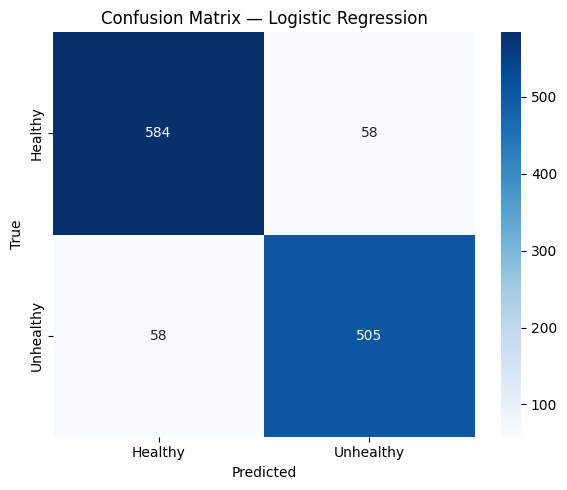


Top 5 Grid Search Results:


,param_solver,param_penalty,param_C,mean_test_score,std_test_score,rank_test_score
0,saga,elasticnet,10.0,0.898838,0.005086,1
1,lbfgs,l2,10.0,0.898632,0.004825,2
2,saga,l2,10.0,0.898627,0.005431,3
3,saga,l2,10.0,0.898627,0.005431,3
4,saga,l2,10.0,0.898627,0.005431,3


In [9]:
# =========================
# Section 8A — Generate CamemBERT Embeddings  (with .npy cache)
# =========================
# CamemBERT embedding is expensive (~5–20 min on CPU for a few thousand sentences).
# We cache the results to .npy files so subsequent runs skip this step.
#
# IMPORTANT: run Section 5 (CamemBERT Vectorizer cell) before this cell so that
#            get_camembert_embeddings, camembert_tokenizer, camembert_model, and
#            device are all defined in the kernel.

import os

CACHE_TRAIN = 'X_train_cam.npy'   # cached training embeddings (shape: n_train × 768)
CACHE_TEST  = 'X_test_cam.npy'    # cached test embeddings    (shape: n_test  × 768)

if os.path.exists(CACHE_TRAIN) and os.path.exists(CACHE_TEST):
    # Load pre-computed embeddings from disk — skips the slow forward pass
    X_train_cam = np.load(CACHE_TRAIN)
    X_test_cam  = np.load(CACHE_TEST)
    print("Loaded embeddings from cache.")
else:
    # Run the full CamemBERT forward pass for every sentence in train and test
    # get_camembert_embeddings is defined in Section 5 (cell above)
    X_train_cam = get_camembert_embeddings(
        X_train_texts.tolist(), camembert_tokenizer, camembert_model, device
    )
    X_test_cam = get_camembert_embeddings(
        X_test_texts.tolist(), camembert_tokenizer, camembert_model, device
    )
    # Persist to disk so the next run loads from cache
    np.save(CACHE_TRAIN, X_train_cam)
    np.save(CACHE_TEST,  X_test_cam)
    print("Embeddings computed and saved to cache.")

# Verify shapes: should be (n_samples, 768)
print(f"Train: {X_train_cam.shape} | Test: {X_test_cam.shape}")

# =========================
# Section 8B — Train & Evaluate: LR + CamemBERT
# =========================
# LRClassifier is defined in Section 7.
# It runs GridSearchCV internally during .fit() and stores the best estimator.
print('='*50)
print('Logistic Regression with CamemBERT Embeddings')
print('='*50)

lr_cam = LRClassifier(cv=5, scoring='f1_macro')
lr_cam.fit(X_train_cam, y_train)   # triggers GridSearch over solver/penalty/C

# evaluate() returns a DataFrame with columns:
#   Model | Class | Accuracy | Precision | Recall | F1-score | Support | Macro avg
results_cam, y_pred_cam = lr_cam.evaluate(
    X_test_cam, y_test, label_encoder, model_name='LR + CamemBERT'
)

# Confusion matrix — rows = true labels, columns = predicted labels
lr_cam.plot_confusion_matrix(y_test, y_pred_cam, label_encoder)

# Display the top 5 hyperparameter combinations found by GridSearch
print('\nTop 5 Grid Search Results:')
lr_cam.top_grid_results(5)

**LR + CamemBERT results interpretation:**

Logistic Regression finds a linear decision boundary in the 768-dimensional CamemBERT embedding space.

- **Solver** (lbfgs / saga / liblinear) — the optimisation algorithm used to find the weights
- **Penalty** (l1 / l2 / elasticnet) — regularisation type: l2 shrinks all weights, l1 drives some to zero (feature selection), elasticnet mixes both
- **C** — inverse regularisation strength: high C → less regularisation → model fits training data more closely (risk of overfitting); low C → stronger regularisation → simpler boundary

## 9. LR + TF-IDF

Logistic Regression with TF-IDF
Running GridSearchCV...
Fitting 5 folds for each of 104 candidates, totalling 520 fits

Best params  : {'C': 10.0, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV score (f1_macro): 0.9693

--- LR + TF-IDF Evaluation ---
      Model     Class Accuracy  Precision  Recall  F1-score  Support Macro avg
LR + TF-IDF   Healthy   0.9701     0.9690  0.9751    0.9720      642      0.97
            Unhealthy              0.9714  0.9645    0.9679      563          


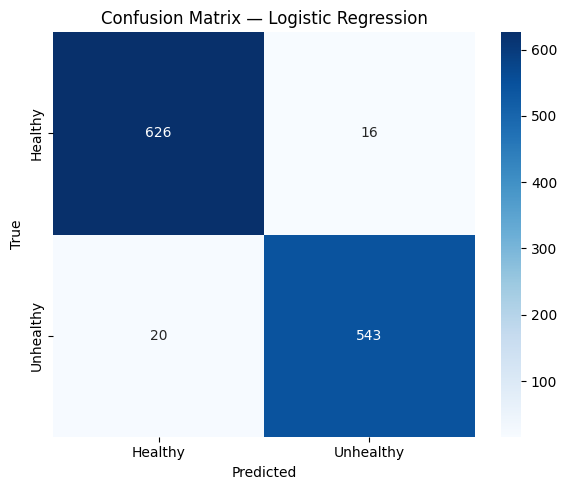


Top 5 Grid Search Results:


,param_solver,param_penalty,param_C,mean_test_score,std_test_score,rank_test_score
0,liblinear,l2,10.0,0.969327,0.004366,1
1,liblinear,l2,10.0,0.969132,0.005223,2
2,saga,l2,10.0,0.969117,0.004705,3
3,saga,l2,10.0,0.969117,0.004705,3
4,saga,l2,10.0,0.969117,0.004705,3


In [10]:
# =========================
# Train & Evaluate: LR + TF-IDF
# =========================
# X_train_tfidf and X_test_tfidf are sparse matrices built in Section 6.
# LRClassifier runs the same GridSearch as in Section 8 but now
# operates on the 5000-feature TF-IDF space instead of 768-dim CamemBERT embeddings.
print('='*50)
print('Logistic Regression with TF-IDF')
print('='*50)

lr_tfidf = LRClassifier(cv=5, scoring='f1_macro')
lr_tfidf.fit(X_train_tfidf, y_train)   # GridSearch over solver/penalty/C on TF-IDF features

# evaluate() produces the same column format as Section 8:
#   Model | Class | Accuracy | Precision | Recall | F1-score | Support | Macro avg
results_tfidf, y_pred_tfidf = lr_tfidf.evaluate(
    X_test_tfidf, y_test, label_encoder, model_name='LR + TF-IDF'
)

# Confusion matrix shows which classes are confused with each other
lr_tfidf.plot_confusion_matrix(y_test, y_pred_tfidf, label_encoder)

print('\nTop 5 Grid Search Results:')
lr_tfidf.top_grid_results(5)

**LR + TF-IDF results interpretation:**

TF-IDF gives the model explicit word-frequency signals rather than dense semantic vectors.
Logistic Regression typically trains faster on sparse TF-IDF features than on dense embeddings,
and often achieves competitive accuracy on clean, domain-specific corpora like this one.

## 10. Cross-Validation (TF-IDF + Best LR Params)

In [11]:
# =========================
# Cross-Validation on full dataset with best params from TF-IDF LR
# =========================
# Purpose: evaluate how well the best LR configuration generalises when trained
# on the FULL dataset (not just 80 %), using 5-fold stratified cross-validation.
# This gives a more reliable performance estimate than a single train/test split.
#
# We re-fit TF-IDF on the full dataset (no held-out test set here) to match
# the cross-validation protocol — each fold's test data is never seen during fitting.

tfidf_full = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_full     = tfidf_full.fit_transform(data['text_nostop'])   # use text_nostop (same column as training)
y_full     = data['encoded_label']

# Reconstruct the best LR model using the hyperparameters found in Section 9
best_lr_cv = LogisticRegression(max_iter=5000, random_state=42, **lr_tfidf.best_params)

# cross_validate runs 5-fold CV and returns per-fold scores
cv_results = cross_validate(
    best_lr_cv, X_full, y_full,
    cv=5,
    scoring=['accuracy', 'f1_macro'],
    n_jobs=-1    # use all CPU cores
)

print('Cross-Validation Results (5-fold, TF-IDF + Best LR)')
print(f'  Mean Accuracy : {cv_results["test_accuracy"].mean():.4f} ± {cv_results["test_accuracy"].std():.4f}')
print(f'  Mean F1 Macro : {cv_results["test_f1_macro"].mean():.4f} ± {cv_results["test_f1_macro"].std():.4f}')

Cross-Validation Results (5-fold, TF-IDF + Best LR)
  Mean Accuracy : 0.9578 ± 0.0097
  Mean F1 Macro : 0.9576 ± 0.0097


## 11. Model Comparison Summary

In [12]:
# =========================
# Model Comparison Summary
# =========================
# Side-by-side comparison of LR + CamemBERT vs LR + TF-IDF.
# Accuracy and Macro avg are stored only in the first row of results_cam/results_tfidf
# (where the Model column is non-empty) — we filter for that row to extract the values.

summary = pd.DataFrame([
    {
        'Model'       : 'LR + CamemBERT',
        'Best Solver' : lr_cam.best_params.get('solver',  ''),
        'Best C'      : lr_cam.best_params.get('C',       ''),
        'Best Penalty': lr_cam.best_params.get('penalty', ''),
        # Accuracy and Macro avg appear only in the first data row (Model != '')
        'Accuracy'    : results_cam.loc[results_cam['Accuracy'] != '', 'Accuracy'].values[0],
        'Macro avg'   : results_cam.loc[results_cam['Macro avg'] != '', 'Macro avg'].values[0],
    },
    {
        'Model'       : 'LR + TF-IDF',
        'Best Solver' : lr_tfidf.best_params.get('solver',  ''),
        'Best C'      : lr_tfidf.best_params.get('C',       ''),
        'Best Penalty': lr_tfidf.best_params.get('penalty', ''),
        'Accuracy'    : results_tfidf.loc[results_tfidf['Accuracy'] != '', 'Accuracy'].values[0],
        'Macro avg'   : results_tfidf.loc[results_tfidf['Macro avg'] != '', 'Macro avg'].values[0],
    },
])

print('\n=== Model Comparison ===')
display(summary)

# Persist comparison to CSV for reporting
summary.to_csv('results_lr_comparison.csv', index=False)
print('Saved → results_lr_comparison.csv')


=== Model Comparison ===


,Model,Best Solver,Best C,Best Penalty,Accuracy,Macro avg
0,LR + CamemBERT,saga,10.0,elasticnet,0.9037,0.9033
1,LR + TF-IDF,liblinear,10.0,l2,0.9701,0.9700


Saved → results_lr_comparison.csv


In [13]:
# =========================
# Final Results Tables — CamemBERT and TF-IDF
# =========================
# Display both per-class results tables for a clean final view.
# These DataFrames were produced by evaluate() in Sections 8 and 9.

print("LR + CamemBERT — Per-Class Results")
display(results_cam)

print("\nLR + TF-IDF — Per-Class Results")
display(results_tfidf)

LR + CamemBERT — Per-Class Results


,Model,Class,Accuracy,Precision,Recall,F1-score,Support,Macro avg
0,LR + CamemBERT,Healthy,0.9037,0.9097,0.9097,0.9097,642,0.9033
1,,Unhealthy,,0.8970,0.8970,0.8970,563,



LR + TF-IDF — Per-Class Results


,Model,Class,Accuracy,Precision,Recall,F1-score,Support,Macro avg
0,LR + TF-IDF,Healthy,0.9701,0.9690,0.9751,0.9720,642,0.97
1,,Unhealthy,,0.9714,0.9645,0.9679,563,


In [14]:
# =========================
# Save Train + Test Results
# =========================
import os, json, csv
from datetime import datetime
from sklearn.metrics import accuracy_score, f1_score, classification_report

os.makedirs("machine_learning_results", exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

def get_metrics(y_true, y_pred, le, model_name, split):
    report = classification_report(y_true, y_pred, target_names=le.classes_, output_dict=True)
    return {
        "timestamp":   timestamp,
        "model":       model_name,
        "split":       split,
        "accuracy":    round(accuracy_score(y_true, y_pred), 4),
        "f1_macro":    round(f1_score(y_true, y_pred, average="macro",    zero_division=0), 4),
        "f1_weighted": round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "healthy_precision":   round(report["Healthy"]["precision"],  4),
        "healthy_recall":      round(report["Healthy"]["recall"],     4),
        "healthy_f1":          round(report["Healthy"]["f1-score"],   4),
        "unhealthy_precision": round(report["Unhealthy"]["precision"],4),
        "unhealthy_recall":    round(report["Unhealthy"]["recall"],   4),
        "unhealthy_f1":        round(report["Unhealthy"]["f1-score"], 4),
    }

rows = []

# LR + CamemBERT
rows.append(get_metrics(y_train, lr_cam.predict(X_train_cam),   label_encoder, "LR+CamemBERT", "train"))
rows.append(get_metrics(y_test,  y_pred_cam,                     label_encoder, "LR+CamemBERT", "test"))

# LR + TF-IDF
rows.append(get_metrics(y_train, lr_tfidf.predict(X_train_tfidf), label_encoder, "LR+TF-IDF", "train"))
rows.append(get_metrics(y_test,  y_pred_tfidf,                    label_encoder, "LR+TF-IDF",  "test"))

# Save CSV
csv_path = "machine_learning_results/LR_results.csv"
file_exists = os.path.exists(csv_path)
with open(csv_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    if not file_exists:
        writer.writeheader()
    writer.writerows(rows)

# Save JSON
json_path = f"machine_learning_results/LR_results_{timestamp}.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(rows, f, indent=2)

# Print summary
print("\n" + "="*55)
print("  LR RESULTS SAVED")
print("="*55)
for r in rows:
    print(f"  {r['model']:<20} {r['split']:<6} acc={r['accuracy']:.4f}  f1={r['f1_macro']:.4f}")
print(f"\n  CSV  → {csv_path}")
print(f"  JSON → {json_path}")



  LR RESULTS SAVED
  LR+CamemBERT         train  acc=0.9365  f1=0.9362
  LR+CamemBERT         test   acc=0.9037  f1=0.9033
  LR+TF-IDF            train  acc=0.9990  f1=0.9990
  LR+TF-IDF            test   acc=0.9701  f1=0.9700

  CSV  → machine_learning_results/LR_results.csv
  JSON → machine_learning_results/LR_results_20260603_172116.json
